# Hyperliquid BTC Trade Analysis with `polaris_data`

This notebook uses `polaris-data>=0.8.3` to:

- discover the Hyperliquid BTC market in Polaris
- fetch a bounded window of OHLCV bars
- fetch the matching trade stream
- plot price and trade flow for quick inspection


In [9]:
%pip install -U "polaris-data>=0.8.3" pandas matplotlib

/Users/hilliamtung/conductor/workspaces/polaris-notebooks/indianapolis-v1/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
from polaris_data import PolarisClient
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

In [11]:
source = "hyperliquid"
market = "BTC"

# Use an explicit bounded range with polaris-data 0.8.3.
start = "2026-06-29T19:00:00Z"
end = "2026-06-29T20:00:00Z"

In [12]:
with PolarisClient() as client:
    catalog = client.catalog(source=source, market=market)

market_info = catalog["sources"][0]["markets"][0]
market_info

{'id': 'BTC',
 'start': '2026-05-18T14:17:14.660Z',
 'end': '2026-06-29T22:30:01.445Z',
 'source': 'manifest',
 'categories': ['perp'],
 'access': {'status': 'open', 'public_cutoff_date': None}}

In [13]:
with PolarisClient() as client:
    bars = client.ohlcv(
        source=source,
        market=market,
        interval="1m",
        from_=start,
        to=end,
    )
    trades = client.trades(
        source=source,
        market=market,
        from_=start,
        to=end,
    )

In [14]:
bars_df = pd.DataFrame(bars)
bars_df["timestamp"] = pd.to_datetime(bars_df["timestamp"], unit="us", utc=True)
bars_df = bars_df.set_index("timestamp").sort_index()

trades_df = pd.json_normalize(trades)
trades_df["timestamp"] = pd.to_datetime(trades_df["timestamp"], unit="us", utc=True)
trades_df = trades_df.rename(
    columns={
        "data.price": "price",
        "data.quantity": "quantity",
        "data.side": "side",
    }
)
trades_df = trades_df.sort_values("timestamp")
trades_df[["timestamp", "price", "quantity", "side"]].head()

,timestamp,price,quantity,side
0,2026-06-29 19:00:00.032000+00:00,60275,0.00150,buy
1,2026-06-29 19:00:00.032000+00:00,60275,0.00065,buy
2,2026-06-29 19:00:00.507000+00:00,60275,0.00017,buy
3,2026-06-29 19:00:00.507000+00:00,60276,0.00017,buy
4,2026-06-29 19:00:00.507000+00:00,60277,0.00017,buy


In [15]:
trade_summary = pd.DataFrame(
    {
        "trade_count": [len(trades_df)],
        "buy_volume": [trades_df.loc[trades_df["side"] == "buy", "quantity"].sum()],
        "sell_volume": [trades_df.loc[trades_df["side"] == "sell", "quantity"].sum()],
        "notional_usd": [(trades_df["price"] * trades_df["quantity"]).sum()],
    }
)
trade_summary

,trade_count,buy_volume,sell_volume,notional_usd
0,18334,756.33067,508.68368,7.628556e+07


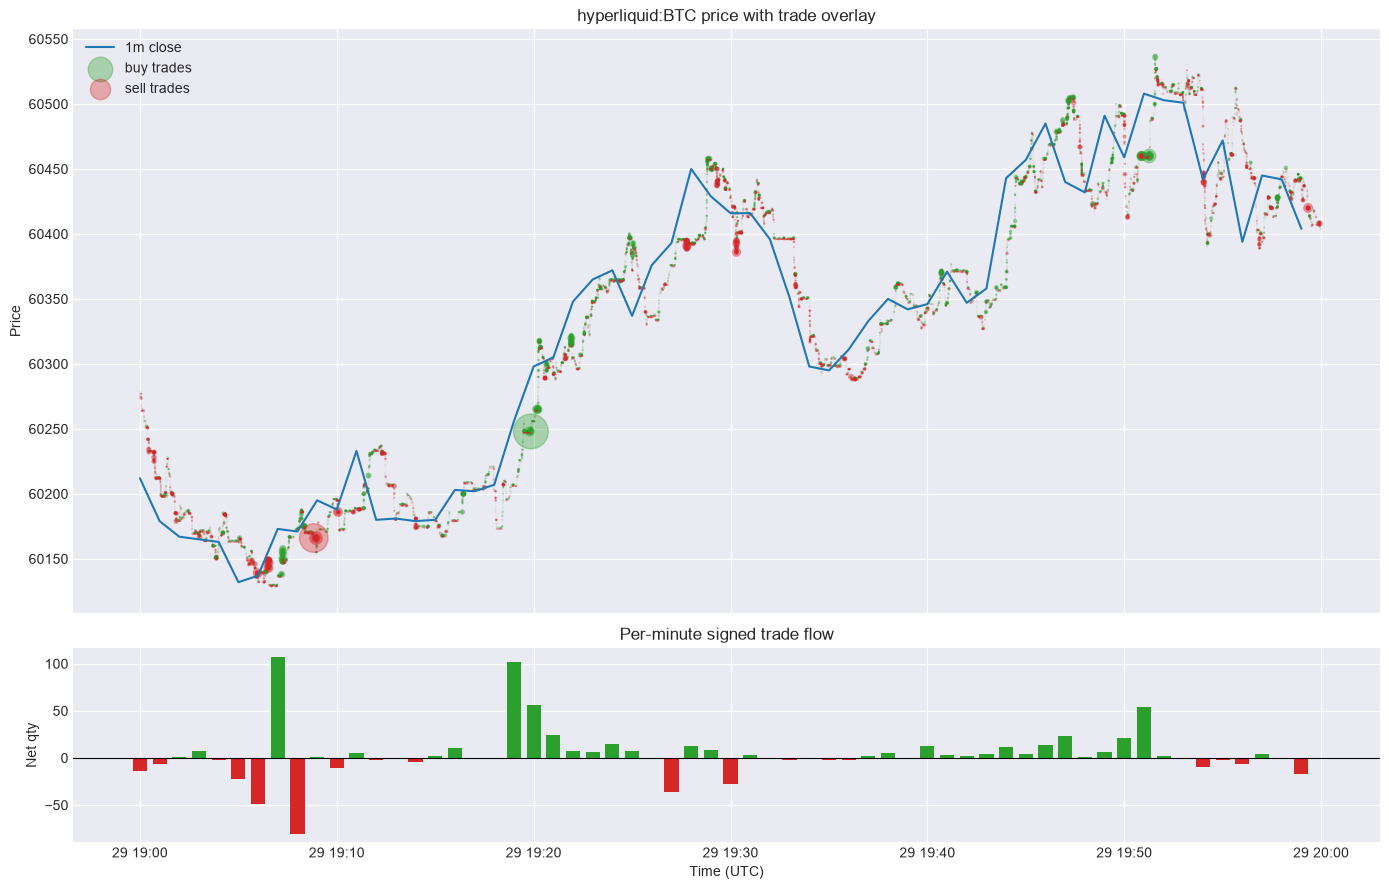

In [16]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(bars_df.index, bars_df["close"], color="#1f77b4", linewidth=1.5, label="1m close")

buy_trades = trades_df[trades_df["side"] == "buy"]
sell_trades = trades_df[trades_df["side"] == "sell"]

axes[0].scatter(
    buy_trades["timestamp"],
    buy_trades["price"],
    s=buy_trades["quantity"] * 8,
    alpha=0.35,
    color="#2ca02c",
    label="buy trades",
)
axes[0].scatter(
    sell_trades["timestamp"],
    sell_trades["price"],
    s=sell_trades["quantity"] * 8,
    alpha=0.35,
    color="#d62728",
    label="sell trades",
)
axes[0].set_title(f"{source}:{market} price with trade overlay")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

trade_flow = (
    trades_df.assign(
        signed_qty=trades_df["quantity"].where(trades_df["side"] == "buy", -trades_df["quantity"])
    )
    .set_index("timestamp")["signed_qty"]
    .resample("1min")
    .sum()
    .fillna(0)
)
bar_colors = trade_flow.apply(lambda value: "#2ca02c" if value >= 0 else "#d62728")
axes[1].bar(trade_flow.index, trade_flow.values, width=0.0005, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Net qty")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_title("Per-minute signed trade flow")

plt.tight_layout()
plt.show()